In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import sqlite3

# Establish connection globally with a timeout for lock acquisition
conn = sqlite3.connect('sales_analysis.db', timeout=10)
cursor = conn.cursor()

In [2]:
import sqlite3

if 'conn' in locals() and conn: # Check if 'conn' exists and is not None
    conn.close()
    print("Previous database connection closed.")

# Re-establish connection globally with a timeout for lock acquisition
conn = sqlite3.connect('sales_analysis.db', timeout=10)
cursor = conn.cursor()
print("Database connection re-established.")

Database connection re-established.


In [7]:
import datetime
import numpy as np

# Get the last order_id to continue from there
cursor.execute('SELECT MAX(order_id) FROM online_sales')
last_order_id = cursor.fetchone()[0]
if last_order_id is None:
    last_order_id = 0
next_order_id = last_order_id + 1

# Define the date range for new historical data (Jan 2025 - May 2026)
start_date = datetime.date(2025, 1, 1)
end_date = datetime.date(2026, 5, 31)

new_sales_data = []
current_date = start_date
while current_date <= end_date:
    # Generate random number of orders per day (e.g., 1 to 3 orders)
    num_orders_per_day = np.random.randint(1, 4)
    for _ in range(num_orders_per_day):
        amount = round(np.random.uniform(500, 3500), 2)  # Random sales amount
        product_id = np.random.randint(101, 106)      # Random product_id (101-105)
        new_sales_data.append((next_order_id, current_date.strftime('%Y-%m-%d'), amount, product_id))
        next_order_id += 1
    current_date += datetime.timedelta(days=1);

# Insert the new historical data
cursor.executemany('''
INSERT INTO online_sales
(order_id, order_date, amount, product_id)
VALUES (?, ?, ?, ?)
''', new_sales_data)

conn.commit()
print(f"Inserted {len(new_sales_data)} new historical sales records from {start_date} to {end_date}.")

# Verify by fetching a few records
cursor.execute('SELECT * FROM online_sales ORDER BY order_date DESC LIMIT 5')
print("\nLast 5 records after insertion:")
for row in cursor.fetchall():
    print(row)

Inserted 1028 new historical sales records from 2025-01-01 to 2026-05-31.

Last 5 records after insertion:
(1036, '2026-05-31', 1972.91, 101)
(1037, '2026-05-31', 2096.53, 102)
(1038, '2026-05-31', 3185.18, 102)
(1034, '2026-05-30', 1323.6, 105)
(1035, '2026-05-30', 1231.11, 103)


Now that the historical data has been added, please re-run all the analysis cells from "Monthly Revenue Analysis" downwards to see the updated sales trends and metrics.

In [ ]:
cursor.execute('DROP TABLE IF EXISTS online_sales')
conn.commit()

In [4]:
# CREATE online_sales TABLE
cursor.execute('''
CREATE TABLE IF NOT EXISTS online_sales (
    order_id INTEGER PRIMARY KEY,
    order_date TEXT,
    amount REAL,
    product_id INTEGER
)
''')
conn.commit()

In [5]:
#INSERT SAMPLE DATA

# Clear existing data to prevent IntegrityError if table exists and wasn't dropped
cursor.execute('DELETE FROM online_sales')

sales_data = [
(1, '2024-01-05', 1200.00, 101),
(2, '2024-01-15', 800.00, 102),
(3, '2024-02-10', 1500.00, 103),
(4, '2024-02-18', 950.00, 101),
(5, '2024-03-02', 2100.00, 104),
(6, '2024-03-20', 1800.00, 102),
(7, '2024-04-05', 2500.00, 105),
(8, '2024-04-12', 1700.00, 101),
(9, '2024-05-01', 3000.00, 103),
(10, '2024-05-15', 2800.00, 104)
]

cursor.executemany('''
INSERT INTO online_sales
(order_id, order_date, amount, product_id)
VALUES (?, ?, ?, ?)
''', sales_data)

conn.commit()

## Sales Trend Analysis

### 1. Monthly Revenue Analysis

Monthly Revenue Analysis:
| sales_month   |   total_revenue |
|:--------------|----------------:|
| 2024-01       |          2000   |
| 2024-02       |          2450   |
| 2024-03       |          3900   |
| 2024-04       |          4200   |
| 2024-05       |          5800   |
| 2025-01       |        132021   |
| 2025-02       |        109959   |
| 2025-03       |        153923   |
| 2025-04       |        117682   |
| 2025-05       |        137542   |
| 2025-06       |         99768.8 |
| 2025-07       |        128372   |
| 2025-08       |        136781   |
| 2025-09       |        103609   |
| 2025-10       |        117472   |
| 2025-11       |        121288   |
| 2025-12       |        113516   |
| 2026-01       |        131391   |
| 2026-02       |        125081   |
| 2026-03       |        125128   |
| 2026-04       |        108488   |
| 2026-05       |        131533   |


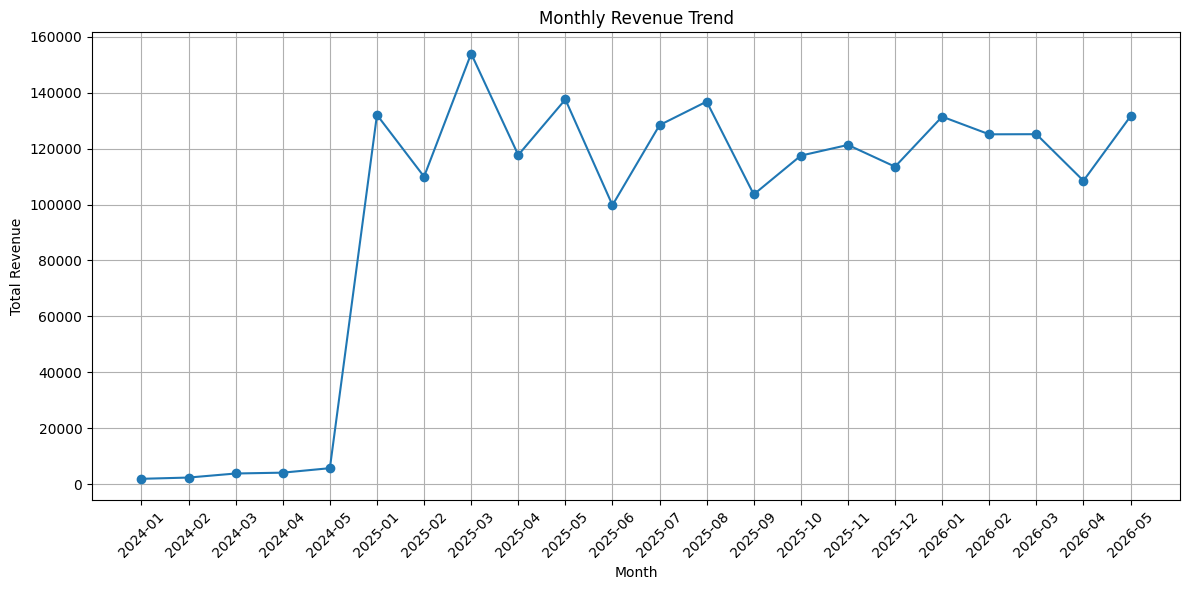

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Query for Monthly Revenue Analysis
monthly_revenue_query = '''
SELECT
    strftime('%Y-%m', order_date) AS sales_month,
    SUM(amount) AS total_revenue
FROM
    online_sales
GROUP BY
    sales_month
ORDER BY
    sales_month;
'''

# Execute query and load into pandas DataFrame
monthly_revenue_df = pd.read_sql_query(monthly_revenue_query, conn);

# Display the results
print("Monthly Revenue Analysis:")
print(monthly_revenue_df.to_markdown(index=False))

# Plotting Monthly Revenue Trend
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue_df['sales_month'], monthly_revenue_df['total_revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Order Volume Analysis

In [10]:
# Query for Order Volume Analysis
order_volume_query = '''
SELECT
    strftime('%Y-%m', order_date) AS sales_month,
    COUNT(order_id) AS total_orders
FROM
    online_sales
GROUP BY
    sales_month
ORDER BY
    sales_month;
'''

# Execute query and load into pandas DataFrame
order_volume_df = pd.read_sql_query(order_volume_query, conn)

# Display the results
print("Order Volume Analysis:")
print(order_volume_df.to_markdown(index=False))

Order Volume Analysis:
| sales_month   |   total_orders |
|:--------------|---------------:|
| 2024-01       |              2 |
| 2024-02       |              2 |
| 2024-03       |              2 |
| 2024-04       |              2 |
| 2024-05       |              2 |
| 2025-01       |             68 |
| 2025-02       |             53 |
| 2025-03       |             66 |
| 2025-04       |             57 |
| 2025-05       |             67 |
| 2025-06       |             51 |
| 2025-07       |             60 |
| 2025-08       |             69 |
| 2025-09       |             55 |
| 2025-10       |             58 |
| 2025-11       |             61 |
| 2025-12       |             62 |
| 2026-01       |             67 |
| 2026-02       |             59 |
| 2026-03       |             58 |
| 2026-04       |             55 |
| 2026-05       |             62 |


### 3. Top 3 Months by Revenue

In [11]:
# Query for Top 3 Months by Revenue
top_months_query = '''
SELECT
    strftime('%Y-%m', order_date) AS sales_month,
    SUM(amount) AS total_revenue
FROM
    online_sales
GROUP BY
    sales_month
ORDER BY
    total_revenue DESC
LIMIT 3;
'''

# Execute query and load into pandas DataFrame
top_months_df = pd.read_sql_query(top_months_query, conn)

# Display the results
print("Top 3 Months by Revenue:")
print(top_months_df.to_markdown(index=False))

Top 3 Months by Revenue:
| sales_month   |   total_revenue |
|:--------------|----------------:|
| 2025-03       |          153923 |
| 2025-05       |          137542 |
| 2025-08       |          136781 |


### 4. Product-wise Sales

In [12]:
# Query for Product-wise Sales
product_sales_query = '''
SELECT
    product_id,
    SUM(amount) AS total_sales
FROM
    online_sales
GROUP BY
    product_id
ORDER BY
    total_sales DESC;
'''

# Execute query and load into pandas DataFrame
product_sales_df = pd.read_sql_query(product_sales_query, conn)

# Display the results
print("Product-wise Sales:")
print(product_sales_df.to_markdown(index=False))

Product-wise Sales:
|   product_id |   total_sales |
|-------------:|--------------:|
|          104 |        464723 |
|          101 |        445232 |
|          102 |        405605 |
|          105 |        398193 |
|          103 |        398152 |


### 5. Average Order Value

In [13]:
# Query for Average Order Value
avg_order_value_query = '''
SELECT
    AVG(amount) AS average_order_value
FROM
    online_sales;
'''

# Execute query and load into pandas DataFrame
avg_order_value_df = pd.read_sql_query(avg_order_value_query, conn)

# Display the results
print("Average Order Value:")
print(avg_order_value_df.to_markdown(index=False))

Average Order Value:
|   average_order_value |
|----------------------:|
|               2034.59 |


### 6. Minimum and Maximum Order Values

In [14]:
# Query for Minimum and Maximum Order Values
min_max_order_query = '''
SELECT
    MIN(amount) AS min_order_value,
    MAX(amount) AS max_order_value
FROM
    online_sales;
'''

# Execute query and load into pandas DataFrame
min_max_order_df = pd.read_sql_query(min_max_order_query, conn)

# Display the results
print("Minimum and Maximum Order Values:")
print(min_max_order_df.to_markdown(index=False))

Minimum and Maximum Order Values:
|   min_order_value |   max_order_value |
|------------------:|------------------:|
|            503.48 |           3499.18 |


### Final Step: Close the database connection

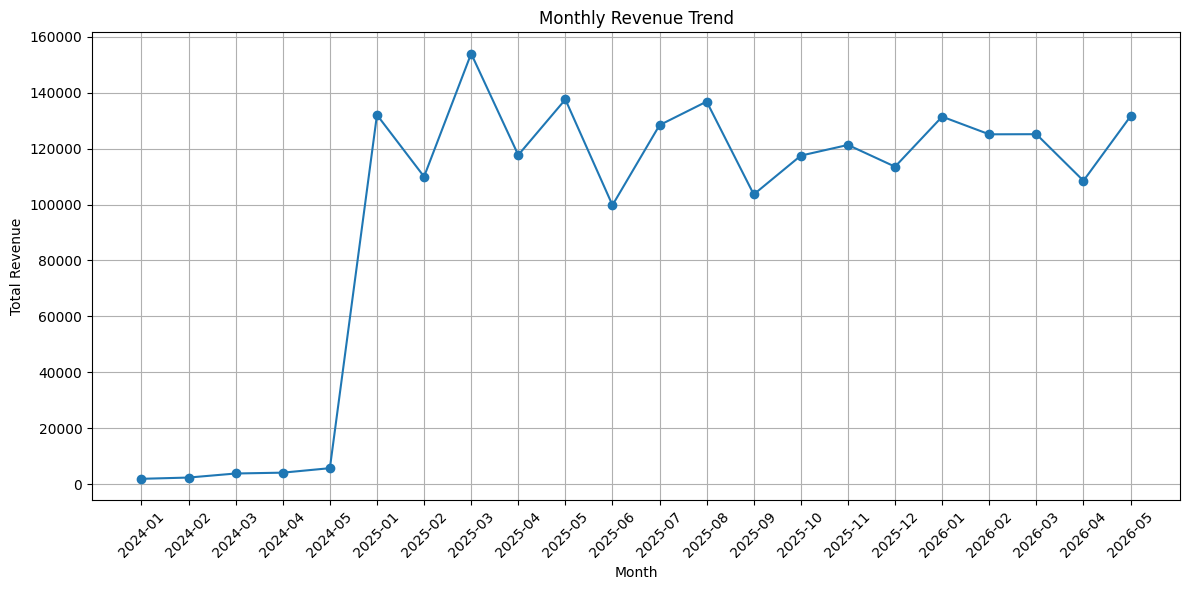

In [16]:
# Plotting Monthly Revenue Trend using the existing monthly_revenue_df
plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue_df['sales_month'], monthly_revenue_df['total_revenue'], marker='o', linestyle='-')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Close the connection
conn.close()
print("Database connection closed.")

Database connection closed.
